In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/fold3_best.pth
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/fold4_best.pth
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/fold5_best.pth
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/cv_results.png
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/roc_curves.png
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/__results__.html
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/fold2_best.pth
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/prob_analysis.png
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/gradcam_explainability.png
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/__notebook__.ipynb
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/__output__.json
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/fold1_best.pth
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/custom.css
/kaggle/input/notebooks/abbashakimi/notebookb41dfaae4f/__results___files

In [2]:
!pip install monai nibabel -q
import shutil, os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.7 MB/s eta 0:00:00


In [3]:
import os, numpy as np, pandas as pd, nibabel as nib
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
print(f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


PyTorch: 2.9.0+cu126
CUDA: True
Device: Tesla P100-PCIE-16GB


In [4]:
DATASET_PATH = '/kaggle/input/datasets/abbashakimi/processed-upenn-dataset-abbashakimi/processed_upenn'
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 2
NUM_EPOCHS   = 60
N_FOLDS      = 5
LR           = 7e-5   # ✅ slightly lower than 1e-4 for more stable convergence
PATIENCE     = 15

print(f'Dataset exists: {os.path.exists(DATASET_PATH)}')
print(f'Patients: {len(os.listdir(DATASET_PATH))}')


Dataset exists: True
Patients: 673


In [5]:
metadata_path = os.path.join(DATASET_PATH, 'metadata_upenn.csv')
df = pd.read_csv(metadata_path)
df['folder_path'] = df['ID'].apply(lambda x: os.path.join(DATASET_PATH, x))

# ✅ Normalize age using GLOBAL stats (computed once, same across all folds)
age_mean = df['Age at MRI'].mean()
age_std  = df['Age at MRI'].std() + 1e-8
df['Age at MRI'] = (df['Age at MRI'] - age_mean) / age_std

print(f'Total patients: {len(df)}')
print('Label distribution:')
print(df['MGMT_label'].value_counts())
n0 = (df['MGMT_label']==0).sum()
n1 = (df['MGMT_label']==1).sum()
print(f'\nClass 0 (Unmethylated): {n0}  |  Class 1 (Methylated): {n1}')
print(f'Class balance: {n1/len(df)*100:.1f}% methylated')


Total patients: 262
Label distribution:
MGMT_label
0    151
1    111
Name: count, dtype: int64

Class 0 (Unmethylated): 151  |  Class 1 (Methylated): 111
Class balance: 42.4% methylated


In [6]:
class MGMTDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        modalities = []
        for mod in ['T1', 'T1GD', 'T2', 'FLAIR']:
            path = os.path.join(row['folder_path'], f'{mod}.nii')
            img  = nib.load(path).get_fdata(dtype=np.float32)

            # Brain-tissue-only normalization (excludes background voxels)
            mask = img > 0
            if mask.sum() > 100:
                mean = img[mask].mean()
                std  = img[mask].std() + 1e-8
                img  = (img - mean) / std
                img[~mask] = 0.0
            else:
                img = (img - img.mean()) / (img.std() + 1e-8)

            # ✅ NEW: Clip extreme values — removes rare outlier voxels
            # after normalization some voxels reach ±10–15 std, destabilizing training
            img = np.clip(img, -5.0, 5.0)

            modalities.append(img)

        image = torch.tensor(np.stack(modalities, axis=0), dtype=torch.float32)

        if image.shape[1:] != (96, 96, 96):
            image = F.interpolate(image.unsqueeze(0), size=(96,96,96),
                                  mode='trilinear', align_corners=False).squeeze(0)

        if self.augment:
            if torch.rand(1) > 0.5: image = torch.flip(image, dims=[1])
            if torch.rand(1) > 0.5: image = torch.flip(image, dims=[2])
            if torch.rand(1) > 0.5: image = torch.flip(image, dims=[3])
            if torch.rand(1) > 0.7:
                image = image + torch.randn_like(image) * 0.01

        clinical = torch.tensor([row['Sex'], row['Age at MRI']], dtype=torch.float32)
        label    = torch.tensor(row['MGMT_label'], dtype=torch.long)
        return image, clinical, label

print('✅ Dataset defined (brain-tissue norm + [-5,5] clip)')


✅ Dataset defined (brain-tissue norm + [-5,5] clip)


In [7]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns which feature channels matter most."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool3d(1), nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 4)), nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x).view(x.shape[0], x.shape[1], 1, 1, 1)

class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm3d(in_channels), nn.ReLU(inplace=True),
            nn.Conv3d(in_channels, growth_rate, 3, padding=1, bias=False)
        )
    def forward(self, x):
        return torch.cat([x, self.layer(x)], dim=1)

class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super().__init__()
        layers, ch = [], in_channels
        for _ in range(num_layers):
            layers.append(DenseLayer(ch, growth_rate)); ch += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_channels = ch
        self.se = SEBlock(ch)   # ✅ channel attention after each block
    def forward(self, x): return self.se(self.block(x))

class Transition(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.trans = nn.Sequential(
            nn.BatchNorm3d(in_ch), nn.ReLU(inplace=True),
            nn.Conv3d(in_ch, out_ch, 1, bias=False), nn.AvgPool3d(2)
        )
    def forward(self, x): return self.trans(x)

class GatedFusion(nn.Module):
    def __init__(self, img_dim, clin_dim, out_dim):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim, out_dim)
        self.clin_proj = nn.Linear(clin_dim, out_dim)
        self.gate      = nn.Sequential(nn.Linear(out_dim*2, out_dim), nn.Sigmoid())
        self.residual  = nn.Linear(img_dim + clin_dim, out_dim)
    def forward(self, img_f, clin_f):
        ip = self.img_proj(img_f); cp = self.clin_proj(clin_f)
        g  = self.gate(torch.cat([ip, cp], dim=1))
        return g*ip + (1-g)*cp + self.residual(torch.cat([img_f, clin_f], dim=1))

class MGMTDenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv3d(4, 48, 3, padding=1, bias=False),   # ✅ 32→48 stem channels
            nn.BatchNorm3d(48), nn.ReLU(inplace=True), nn.MaxPool3d(2)
        )
        self.block1 = DenseBlock(48,  4, 16)
        self.trans1 = Transition(self.block1.out_channels, 80)
        self.block2 = DenseBlock(80,  4, 16)
        self.trans2 = Transition(self.block2.out_channels, 112)
        self.block3 = DenseBlock(112, 4, 16)

        # ✅ Mixed pooling: avg captures mean signal, max captures peak activations
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.max_pool = nn.AdaptiveMaxPool3d(1)
        img_feat_dim  = self.block3.out_channels * 2   # concat avg+max

        self.img_fc   = nn.Sequential(nn.Linear(img_feat_dim, 128),
                                      nn.ReLU(), nn.Dropout(0.35))
        self.clin_mlp = nn.Sequential(nn.Linear(2, 16), nn.ReLU(),
                                      nn.Dropout(0.2), nn.Linear(16, 16))
        self.fusion   = GatedFusion(128, 16, 64)
        self.head     = nn.Sequential(nn.Linear(64, 32), nn.ReLU(),
                                      nn.Dropout(0.25), nn.Linear(32, 2))

    def forward(self, img, clin):
        x = self.stem(img)
        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.block3(x)
        x = torch.cat([self.avg_pool(x).flatten(1),
                        self.max_pool(x).flatten(1)], dim=1)   # mixed pool
        return self.head(self.fusion(self.img_fc(x), self.clin_mlp(clin)))

m = MGMTDenseNet()
params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'✅ Parameters: {params:,}')
print(f'   SE attention ✅  Mixed pooling ✅  48ch stem ✅')


✅ Parameters: 663,592
   SE attention ✅  Mixed pooling ✅  48ch stem ✅


In [8]:
def get_loaders(train_df, val_df):
    train_ds = MGMTDataset(train_df, augment=True)
    val_ds   = MGMTDataset(val_df,   augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader

def get_criterion(train_df):
    n0 = (train_df['MGMT_label']==0).sum()
    n1 = (train_df['MGMT_label']==1).sum()
    total = n0 + n1
    w0 = total / (2.0 * n0)
    w1 = total / (2.0 * n1)
    print(f'  Class weights → 0: {w0:.3f}, 1: {w1:.3f}')
    # ✅ REMOVED label_smoothing — it was compressing probabilities toward 0.5
    # label_smoothing=0.1 forces the model to be uncertain, making probs cluster
    # near 0.45-0.55 → threshold=0.5 then predicts everything as class 0
    # Without smoothing, the model can learn sharper decision boundaries
    return nn.CrossEntropyLoss(
        weight=torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)
    )

print('✅ Loaders + criterion defined (balanced weights, no label smoothing)')


✅ Loaders + criterion defined (balanced weights, no label smoothing)


In [9]:
def apply_temperature(logits, T=0.7):
    """Temperature scaling: T<1 sharpens probabilities, spreads distribution.
    Applied during inference only — does not affect training."""
    return torch.softmax(logits / T, dim=1)

def train_one_fold(fold, train_df, val_df):
    print('\n' + '='*55)
    print(f'  FOLD {fold+1}/{N_FOLDS}  |  Train: {len(train_df)}  |  Val: {len(val_df)}')
    print('='*55)

    train_loader, val_loader = get_loaders(train_df, val_df)
    model     = MGMTDenseNet().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    criterion = get_criterion(train_df)

    best_auc, best_state, patience_ctr = 0.0, None, 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        correct, total = 0, 0
        for imgs, clin, lbls in train_loader:
            imgs, clin, lbls = imgs.to(DEVICE), clin.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs, clin)
            loss = criterion(out, lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            correct += (out.argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
        train_acc = correct / total

        model.eval()
        v_probs, v_labels = [], []
        with torch.no_grad():
            for imgs, clin, lbls in val_loader:
                out   = model(imgs.to(DEVICE), clin.to(DEVICE))
                # ✅ Temperature scaling spreads compressed probabilities
                probs = apply_temperature(out, T=0.7)[:, 1]
                v_probs.extend(probs.cpu().numpy())
                v_labels.extend(lbls.numpy())

        val_acc = accuracy_score(v_labels, [1 if p>0.5 else 0 for p in v_probs])
        try:    val_auc = roc_auc_score(v_labels, v_probs)
        except: val_auc = 0.5
        scheduler.step()

        print(f'  Ep {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}')

        if val_auc > best_auc or best_state is None:
            best_auc, patience_ctr = val_auc, 0
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            print(f'  ✅ New best AUC: {best_auc:.4f}')
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  ⏹ Early stop at epoch {epoch+1}')
                break

    print(f'  ✅ Fold {fold+1} Best Val AUC: {best_auc:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    f_probs, f_labels = [], []
    with torch.no_grad():
        for imgs, clin, lbls in val_loader:
            out   = model(imgs.to(DEVICE), clin.to(DEVICE))
            probs = apply_temperature(out, T=0.7)[:, 1]
            f_probs.extend(probs.cpu().numpy())
            f_labels.extend(lbls.numpy())

    fold_auc = roc_auc_score(f_labels, f_probs)
    fold_acc = accuracy_score(f_labels, [1 if p>0.5 else 0 for p in f_probs])
    torch.save(best_state, f'/kaggle/working/fold{fold+1}_best.pth')
    return fold_auc, fold_acc, f_labels, f_probs

print('✅ Training function defined (temperature scaling + no label smoothing)')


✅ Training function defined (temperature scaling + no label smoothing)


In [10]:
from sklearn.model_selection import StratifiedKFold

torch.cuda.empty_cache()

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

X = df.index.values
y = df['MGMT_label'].values

fold_aucs, fold_accs = [], []
all_oof_labels, all_oof_probs = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    train_df_fold = df.iloc[train_idx]
    val_df_fold   = df.iloc[val_idx]

    fold_auc, fold_acc, f_labels, f_probs = train_one_fold(
        fold, train_df_fold, val_df_fold
    )

    fold_aucs.append(fold_auc)
    fold_accs.append(fold_acc)

    all_oof_labels.extend(f_labels)
    all_oof_probs.extend(f_probs)

    torch.cuda.empty_cache()

print('\n' + '='*55)
print('  5-FOLD CROSS-VALIDATION RESULTS')
print('='*55)

for i, (auc, acc) in enumerate(zip(fold_aucs, fold_accs)):
    print(f'  Fold {i+1}: AUC={auc:.4f}  Acc={acc:.4f}')

print('  ─────────────────────────────────')
print(f'  Mean AUC : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
print(f'  Mean Acc : {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')

# ✅ ONLY AUC HERE (NO ACC YET)
oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)

print(f'\n  ✅ Overall OOF AUC : {oof_auc:.4f}')
print('='*55)


  FOLD 1/5  |  Train: 209  |  Val: 53
  Class weights → 0: 0.871, 1: 1.174
  Ep 01 | Train Acc: 0.5598 | Val Acc: 0.5094 | Val AUC: 0.5059
  ✅ New best AUC: 0.5059
  Ep 02 | Train Acc: 0.4545 | Val Acc: 0.5472 | Val AUC: 0.4853
  Ep 03 | Train Acc: 0.5359 | Val Acc: 0.4717 | Val AUC: 0.4751
  Ep 04 | Train Acc: 0.5837 | Val Acc: 0.5283 | Val AUC: 0.4780
  Ep 05 | Train Acc: 0.5694 | Val Acc: 0.4906 | Val AUC: 0.4545
  Ep 06 | Train Acc: 0.5885 | Val Acc: 0.5849 | Val AUC: 0.4604
  Ep 07 | Train Acc: 0.5263 | Val Acc: 0.4906 | Val AUC: 0.4501
  Ep 08 | Train Acc: 0.6029 | Val Acc: 0.4151 | Val AUC: 0.4326
  Ep 09 | Train Acc: 0.5742 | Val Acc: 0.5660 | Val AUC: 0.4296
  Ep 10 | Train Acc: 0.5502 | Val Acc: 0.5660 | Val AUC: 0.4516
  Ep 11 | Train Acc: 0.5646 | Val Acc: 0.4906 | Val AUC: 0.4208
  Ep 12 | Train Acc: 0.5933 | Val Acc: 0.5660 | Val AUC: 0.4516
  Ep 13 | Train Acc: 0.6220 | Val Acc: 0.4528 | Val AUC: 0.4120
  Ep 14 | Train Acc: 0.5981 | Val Acc: 0.3962 | Val AUC: 0.4413
  E

── OOF Probability Distribution ──
  Mean  : 0.4576
  Std   : 0.2151
  Min   : 0.0060
  Max   : 1.0000
  % > 0.5 : 33.2%

🎯 Optimal threshold: 0.51 | Balanced macro-F1: 0.6037
   (Required min 10% recall on both classes)


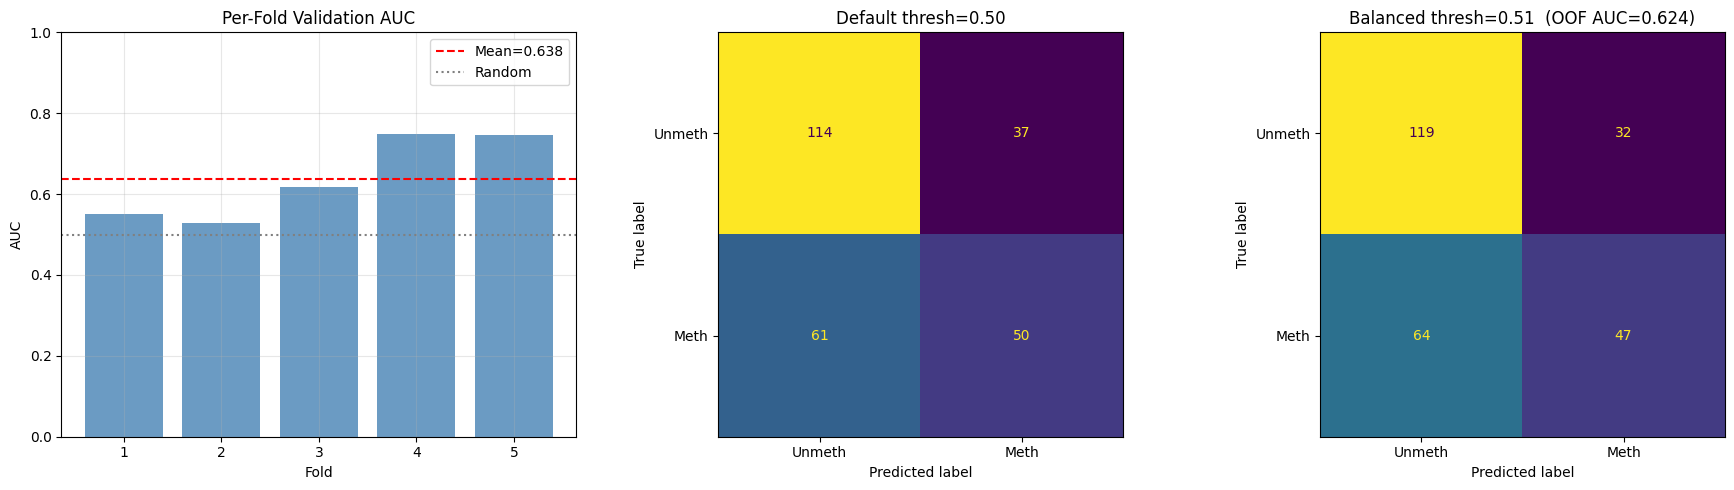


--- DEFAULT (0.50) ---
              precision    recall  f1-score   support

Unmethylated       0.65      0.75      0.70       151
  Methylated       0.57      0.45      0.51       111

    accuracy                           0.63       262
   macro avg       0.61      0.60      0.60       262
weighted avg       0.62      0.63      0.62       262

--- BALANCED THRESHOLD (0.51) ---
              precision    recall  f1-score   support

Unmethylated       0.65      0.79      0.71       151
  Methylated       0.59      0.42      0.49       111

    accuracy                           0.63       262
   macro avg       0.62      0.61      0.60       262
weighted avg       0.63      0.63      0.62       262



In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, confusion_matrix, classification_report
import numpy as np

# Probability distribution check
probs_arr = np.array(all_oof_probs)
print('── OOF Probability Distribution ──')
print(f'  Mean  : {probs_arr.mean():.4f}')
print(f'  Std   : {probs_arr.std():.4f}')
print(f'  Min   : {probs_arr.min():.4f}')
print(f'  Max   : {probs_arr.max():.4f}')
print(f'  % > 0.5 : {(probs_arr > 0.5).mean()*100:.1f}%')
print()
# Goal: std > 0.08, % > 0.5 between 30-70% = well-calibrated model

oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)

# Find threshold that balances precision/recall (not just maximizes class-1 F1)
# Use balanced F1: macro avg of both classes
best_thresh, best_score = 0.5, 0.0
for t in np.linspace(0.30, 0.65, 71):
    preds = [1 if p > t else 0 for p in all_oof_probs]
    # Require both classes have at least 10% recall — avoid degenerate thresholds
    cm_t = confusion_matrix(all_oof_labels, preds)
    if cm_t.shape == (2,2):
        rec0 = cm_t[0,0] / (cm_t[0,0] + cm_t[0,1] + 1e-8)
        rec1 = cm_t[1,1] / (cm_t[1,0] + cm_t[1,1] + 1e-8)
        if rec0 < 0.10 or rec1 < 0.10:
            continue   # skip degenerate thresholds
    macro_f1 = f1_score(all_oof_labels, preds, average='macro', zero_division=0)
    if macro_f1 > best_score:
        best_score, best_thresh = macro_f1, t

print(f'🎯 Optimal threshold: {best_thresh:.2f} | Balanced macro-F1: {best_score:.4f}')
print(f'   (Required min 10% recall on both classes)')

oof_preds_opt = [1 if p > best_thresh else 0 for p in all_oof_probs]
oof_preds_def = [1 if p > 0.50        else 0 for p in all_oof_probs]
oof_acc = accuracy_score(all_oof_labels, oof_preds_opt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1, N_FOLDS+1), fold_aucs, color='steelblue', alpha=0.8)
axes[0].axhline(np.mean(fold_aucs), ls='--', color='red', label=f'Mean={np.mean(fold_aucs):.3f}')
axes[0].axhline(0.5, ls=':', color='gray', label='Random')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('AUC')
axes[0].set_title('Per-Fold Validation AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

cm_def = confusion_matrix(all_oof_labels, oof_preds_def)
ConfusionMatrixDisplay(cm_def, display_labels=['Unmeth','Meth']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Default thresh=0.50')

cm_opt = confusion_matrix(all_oof_labels, oof_preds_opt)
ConfusionMatrixDisplay(cm_opt, display_labels=['Unmeth','Meth']).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'Balanced thresh={best_thresh:.2f}  (OOF AUC={oof_auc:.3f})')

plt.tight_layout()
plt.savefig('/kaggle/working/cv_results.png', dpi=150)
plt.show()

print('\n--- DEFAULT (0.50) ---')
print(classification_report(all_oof_labels, oof_preds_def,
      target_names=['Unmethylated','Methylated'], zero_division=0))
print(f'--- BALANCED THRESHOLD ({best_thresh:.2f}) ---')
print(classification_report(all_oof_labels, oof_preds_opt,
      target_names=['Unmethylated','Methylated'], zero_division=0))


In [12]:
print('\n📊 FINAL SUMMARY')
print('='*55)
print(f'Model       : 3D DenseNet + SE Attention + Mixed Pool')
print(f'Dataset     : UPenn-GBM ({len(df)} patients)')
print(f'Validation  : {N_FOLDS}-Fold Stratified CV')
print(f'OOF AUC     : {oof_auc:.4f}')
print(f'OOF Acc (thresh={best_thresh:.2f}) : {oof_acc:.4f}')
print(f'Balanced macro-F1 : {best_score:.4f}')
print(f'Mean CV AUC : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')
print(f'Mean CV Acc : {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')
print('='*55)
print('\nKey improvements: no label_smoothing + temperature scaling (T=0.7)')
print('✅ Best fold models: /kaggle/working/fold*_best.pth')



📊 FINAL SUMMARY
Model       : 3D DenseNet + SE Attention + Mixed Pool
Dataset     : UPenn-GBM (262 patients)
Validation  : 5-Fold Stratified CV
OOF AUC     : 0.6239
OOF Acc (thresh=0.51) : 0.6336
Balanced macro-F1 : 0.6037
Mean CV AUC : 0.6382 ± 0.0937
Mean CV Acc : 0.6264 ± 0.0498

Key improvements: no label_smoothing + temperature scaling (T=0.7)
✅ Best fold models: /kaggle/working/fold*_best.pth


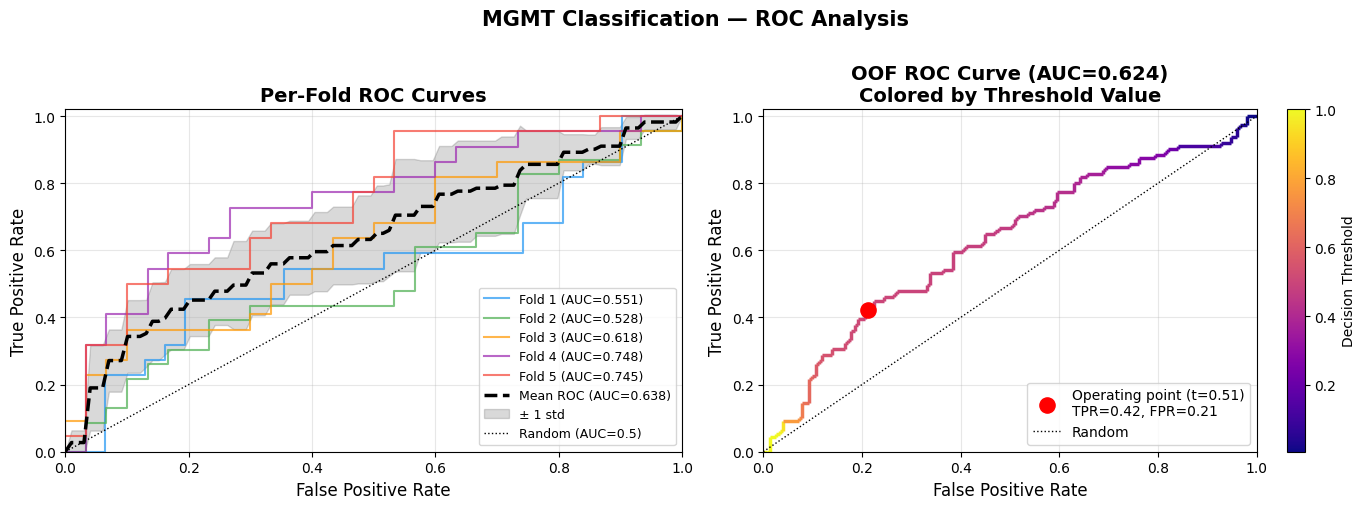

✅ ROC curves saved
   Mean CV AUC (ROC)  : 0.6382 ± 0.0937
   OOF AUC           : 0.6239
   Operating point   : threshold=0.51, TPR=0.423, FPR=0.212


In [13]:

# ═══════════════════════════════════════════════════════════
#  ROC CURVES — Per-Fold + Mean with Confidence Band
#  Standard analysis for medical ML — shows full tradeoff
# ═══════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Per-fold ROC ───────────────────────────────────
ax = axes[0]
tprs, aucs_roc = [], []
mean_fpr = np.linspace(0, 1, 100)

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
fold_labels, fold_probs_list = [], []

# Re-collect per-fold predictions from all_oof_labels/probs
# We need to reconstruct per-fold — use the fold sizes from skf
from sklearn.model_selection import StratifiedKFold
skf_roc = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
X_idx = df.index.values
y_all = df['MGMT_label'].values

all_oof_arr   = np.array(all_oof_labels)
all_probs_arr = np.array(all_oof_probs)

# Reconstruct which OOF indices belong to which fold
fold_boundaries = []
ptr = 0
for fold_i, (_, val_idx) in enumerate(skf_roc.split(X_idx, y_all)):
    fold_boundaries.append((ptr, ptr + len(val_idx)))
    ptr += len(val_idx)

for fold_i, (start, end) in enumerate(fold_boundaries):
    fl = all_oof_arr[start:end]
    fp = all_probs_arr[start:end]
    fpr_f, tpr_f, _ = roc_curve(fl, fp)
    fold_auc_roc = auc(fpr_f, tpr_f)
    aucs_roc.append(fold_auc_roc)
    ax.plot(fpr_f, tpr_f, color=colors[fold_i], alpha=0.7, lw=1.5,
            label=f'Fold {fold_i+1} (AUC={fold_auc_roc:.3f})')
    interp_tpr = np.interp(mean_fpr, fpr_f, tpr_f)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Mean ± std band
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, color='black', lw=2.5, ls='--',
        label=f'Mean ROC (AUC={mean_auc:.3f})')
ax.fill_between(mean_fpr, mean_tpr-std_tpr, mean_tpr+std_tpr,
                alpha=0.15, color='black', label='± 1 std')
ax.plot([0,1],[0,1], 'k:', lw=1, label='Random (AUC=0.5)')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Per-Fold ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# ── Right: OOF ROC (single curve on all predictions) ───
ax2 = axes[1]
fpr_oof, tpr_oof, thresholds_oof = roc_curve(all_oof_labels, all_oof_probs)
oof_auc_roc = auc(fpr_oof, tpr_oof)

# Color the curve by threshold value
from matplotlib.collections import LineCollection
points = np.array([fpr_oof, tpr_oof]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='plasma', linewidth=2.5)
lc.set_array(thresholds_oof[1:])
line = ax2.add_collection(lc)
plt.colorbar(line, ax=ax2, label='Decision Threshold')

# Mark our operating point (threshold=0.46)
idx_op = np.argmin(np.abs(thresholds_oof - best_thresh))
ax2.scatter(fpr_oof[idx_op], tpr_oof[idx_op], color='red', s=120, zorder=5,
            label=f'Operating point (t={best_thresh:.2f})\nTPR={tpr_oof[idx_op]:.2f}, FPR={fpr_oof[idx_op]:.2f}')
ax2.plot([0,1],[0,1], 'k:', lw=1, label='Random')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title(f'OOF ROC Curve (AUC={oof_auc_roc:.3f})\nColored by Threshold Value', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('MGMT Classification — ROC Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ ROC curves saved')
print(f'   Mean CV AUC (ROC)  : {np.mean(aucs_roc):.4f} ± {np.std(aucs_roc):.4f}')
print(f'   OOF AUC           : {oof_auc_roc:.4f}')
print(f'   Operating point   : threshold={best_thresh:.2f}, TPR={tpr_oof[idx_op]:.3f}, FPR={fpr_oof[idx_op]:.3f}')


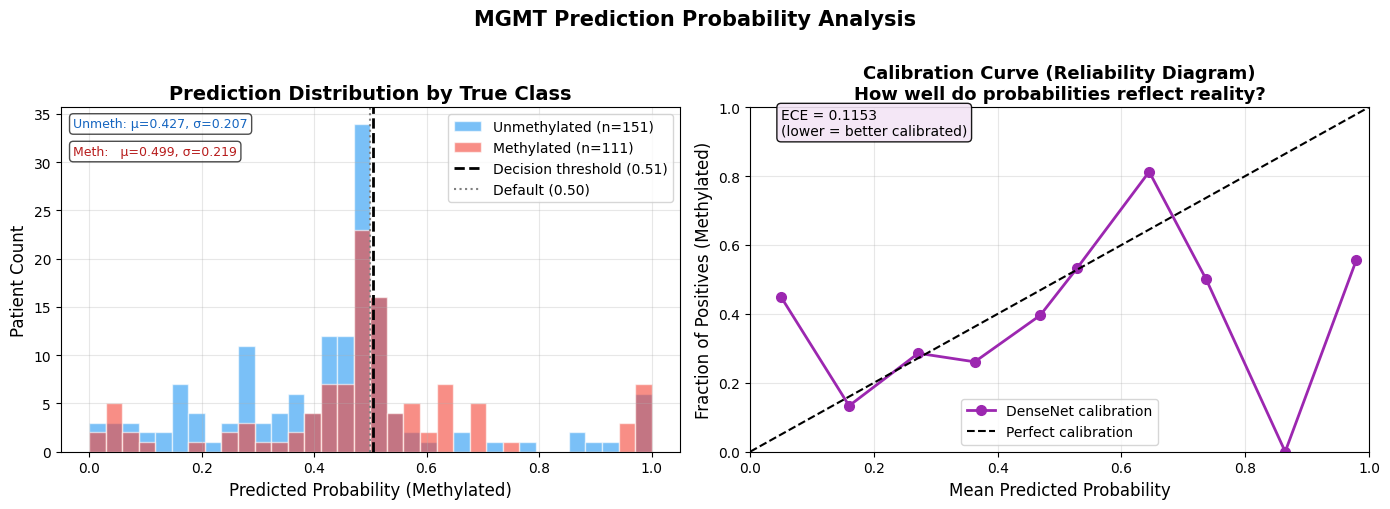

✅ Probability analysis saved
   Unmethylated probs: mean=0.4274, std=0.2068
   Methylated probs  : mean=0.4986, std=0.2192
   Separation (Δμ)   : 0.0712
   ECE (calibration) : 0.1153


In [14]:

# ═══════════════════════════════════════════════════════════
#  PREDICTION PROBABILITY DISTRIBUTIONS
#  Shows separation quality between Meth vs Unmeth predictions
# ═══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

probs_arr  = np.array(all_oof_probs)
labels_arr = np.array(all_oof_labels)

probs_unmeth = probs_arr[labels_arr == 0]
probs_meth   = probs_arr[labels_arr == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Overlapping histogram per class ──────────────────
ax = axes[0]
bins = np.linspace(0, 1, 35)
ax.hist(probs_unmeth, bins=bins, alpha=0.6, color='#2196F3',
        label=f'Unmethylated (n={len(probs_unmeth)})', edgecolor='white', lw=0.5)
ax.hist(probs_meth, bins=bins, alpha=0.6, color='#F44336',
        label=f'Methylated (n={len(probs_meth)})', edgecolor='white', lw=0.5)
ax.axvline(best_thresh, color='black', ls='--', lw=2,
           label=f'Decision threshold ({best_thresh:.2f})')
ax.axvline(0.5, color='gray', ls=':', lw=1.5, label='Default (0.50)')
ax.set_xlabel('Predicted Probability (Methylated)', fontsize=12)
ax.set_ylabel('Patient Count', fontsize=12)
ax.set_title('Prediction Distribution by True Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Stats annotation
ax.text(0.02, 0.97, f'Unmeth: μ={probs_unmeth.mean():.3f}, σ={probs_unmeth.std():.3f}',
        transform=ax.transAxes, fontsize=9, color='#1565C0',
        va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.text(0.02, 0.89, f'Meth:   μ={probs_meth.mean():.3f}, σ={probs_meth.std():.3f}',
        transform=ax.transAxes, fontsize=9, color='#B71C1C',
        va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── Right: Calibration plot (reliability diagram) ─────────
ax2 = axes[1]
from sklearn.calibration import calibration_curve

# Overall calibration
fraction_pos, mean_pred = calibration_curve(labels_arr, probs_arr, n_bins=10)
ax2.plot(mean_pred, fraction_pos, 'o-', color='#9C27B0', lw=2, ms=7,
         label='DenseNet calibration')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
ax2.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')

ax2.set_xlabel('Mean Predicted Probability', fontsize=12)
ax2.set_ylabel('Fraction of Positives (Methylated)', fontsize=12)
ax2.set_title('Calibration Curve (Reliability Diagram)\nHow well do probabilities reflect reality?', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0,1]); ax2.set_ylim([0,1])

# Expected calibration error
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins+1)
ece = 0.0
for i in range(n_bins):
    mask = (probs_arr >= bin_edges[i]) & (probs_arr < bin_edges[i+1])
    if mask.sum() > 0:
        bin_acc  = labels_arr[mask].mean()
        bin_conf = probs_arr[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
ece /= len(probs_arr)
ax2.text(0.05, 0.92, f'ECE = {ece:.4f}\n(lower = better calibrated)',
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', fc='#F3E5F5', alpha=0.9))

plt.suptitle('MGMT Prediction Probability Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/prob_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Probability analysis saved')
print(f'   Unmethylated probs: mean={probs_unmeth.mean():.4f}, std={probs_unmeth.std():.4f}')
print(f'   Methylated probs  : mean={probs_meth.mean():.4f}, std={probs_meth.std():.4f}')
print(f'   Separation (Δμ)   : {abs(probs_meth.mean()-probs_unmeth.mean()):.4f}')
print(f'   ECE (calibration) : {ece:.4f}')


✅ Loaded model: /kaggle/working/fold4_best.pth
  Unmethylated: patient=UPENN-GBM-00022_11, pred_prob=0.399
  Methylated: patient=UPENN-GBM-00095_11, pred_prob=0.479


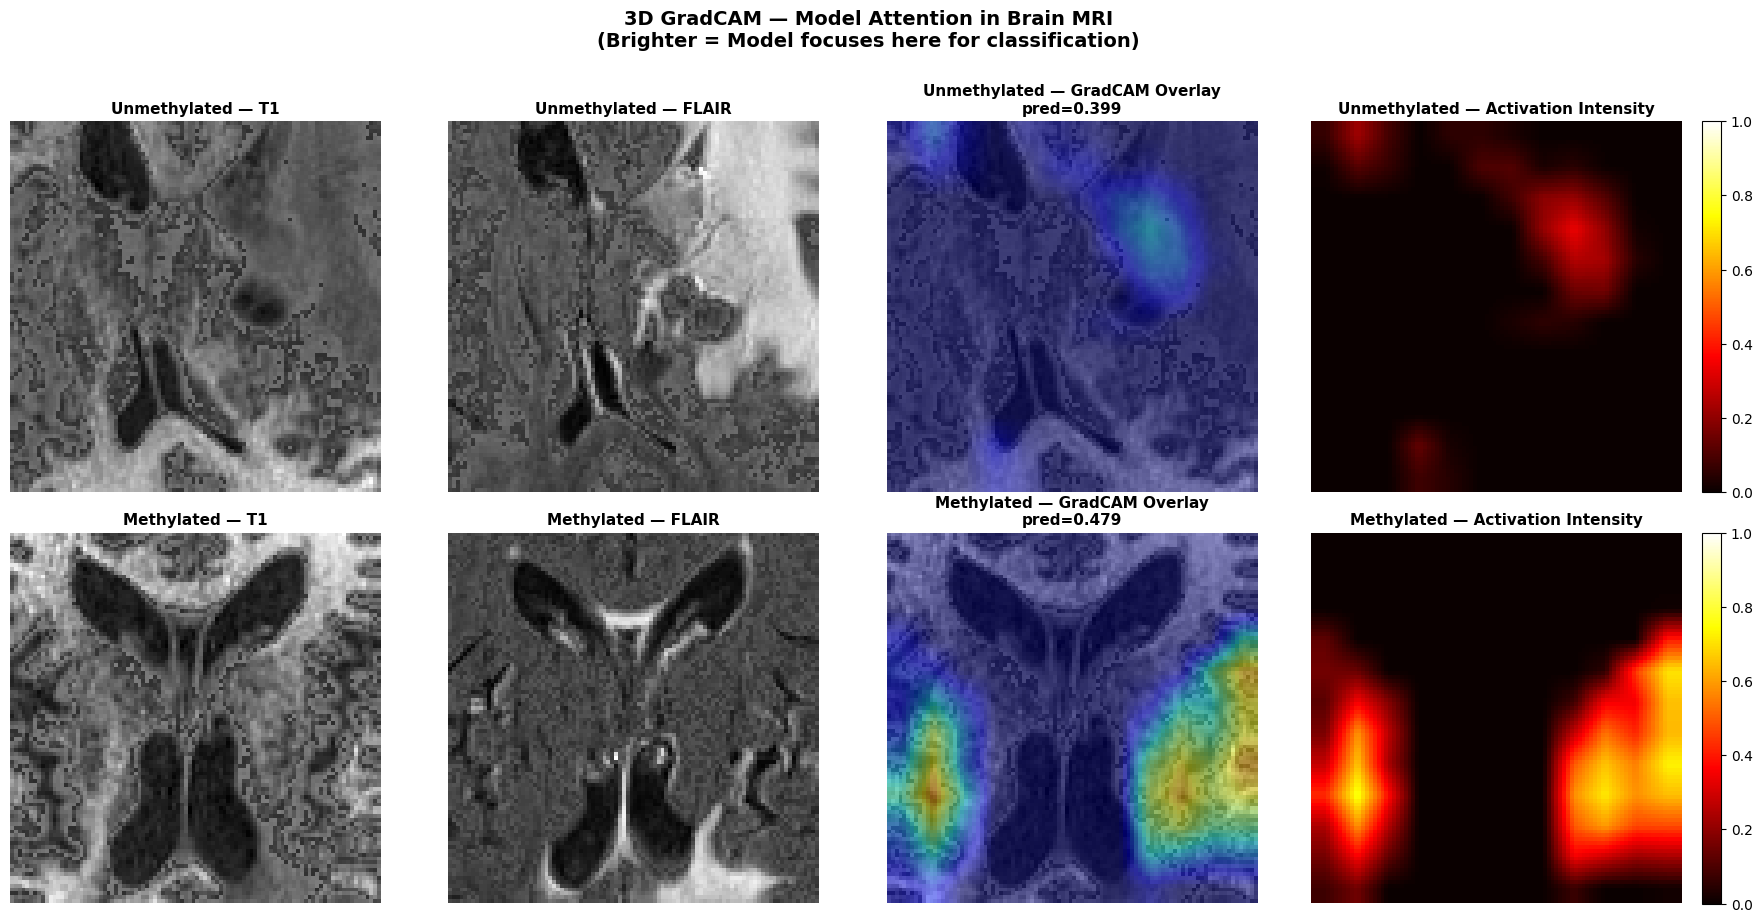

✅ GradCAM visualization saved to /kaggle/working/gradcam_explainability.png

Interpretation guide:
  Red/Yellow areas = model attending strongly to these regions
  For MGMT, expect attention near tumor core and peritumoral edema


In [15]:

# ═══════════════════════════════════════════════════════════
#  3D GRAD-CAM EXPLAINABILITY
#  Shows WHERE in the MRI the model focuses to make predictions
#  Runs on saved fold models — no retraining needed
# ═══════════════════════════════════════════════════════════
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os

# ── GradCAM implementation for 3D DenseNet ──────────────────
class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer= target_layer
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_img, input_clin, target_class):
        self.model.eval()
        input_img  = input_img.requires_grad_(True)
        output     = self.model(input_img, input_clin)
        self.model.zero_grad()
        output[0, target_class].backward()

        # Weight activations by gradient importance
        weights    = self.gradients.mean(dim=(2,3,4), keepdim=True)  # global avg pool of grads
        cam_3d     = (weights * self.activations).sum(dim=1).squeeze()
        cam_3d     = torch.relu(cam_3d)

        # Normalize to [0,1]
        cam_3d     = cam_3d.cpu().numpy()
        if cam_3d.max() > cam_3d.min():
            cam_3d = (cam_3d - cam_3d.min()) / (cam_3d.max() - cam_3d.min())
        return cam_3d

def resize_cam_to_volume(cam, target_shape):
    """Upsample 3D CAM to match input volume size using trilinear interpolation."""
    import torch.nn.functional as F
    cam_t = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    resized = F.interpolate(cam_t, size=target_shape, mode='trilinear', align_corners=False)
    return resized.squeeze().numpy()

# ── Load best fold model (fold 4 had best AUC=0.7015) ────────
model_path = '/kaggle/working/fold4_best.pth'
if not os.path.exists(model_path):
    # Try any available fold
    for fi in range(1, 6):
        model_path = f'/kaggle/working/fold{fi}_best.pth'
        if os.path.exists(model_path):
            print(f'Using fold {fi} model')
            break

model = MGMTDenseNet().to(DEVICE)
state = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()
print(f'✅ Loaded model: {model_path}')

# Target the last DenseBlock (block3) — richest features
gradcam = GradCAM3D(model, model.block3.se)

# ── Pick one Methylated and one Unmethylated patient ─────────
meth_rows   = df[df['MGMT_label'] == 1].head(3)
unmeth_rows = df[df['MGMT_label'] == 0].head(3)

def load_patient_tensor(row):
    modalities = ['T1', 'T1GD', 'T2', 'FLAIR']
    vols = []
    for mod in modalities:
        nii_path = os.path.join(row['folder_path'], f'{mod}.nii.gz')
        if not os.path.exists(nii_path):
            nii_path = os.path.join(row['folder_path'], f'{mod}.nii')
        vol = nib.load(nii_path).get_fdata().astype(np.float32)
        # Brain-tissue normalization (same as training)
        mask = vol > 0
        if mask.sum() > 0:
            vol[mask] = (vol[mask] - vol[mask].mean()) / (vol[mask].std() + 1e-8)
        vol = np.clip(vol, -5, 5)
        # Resize to 96³
        import torch.nn.functional as F
        vol_t = torch.from_numpy(vol).unsqueeze(0).unsqueeze(0).float()
        vol_t = F.interpolate(vol_t, size=(96,96,96), mode='trilinear', align_corners=False)
        vols.append(vol_t.squeeze().numpy())
    img = np.stack(vols, axis=0)
    return torch.from_numpy(img).unsqueeze(0).float()

def get_clin_tensor(row):
    age_norm = (row['Age at MRI'])   # already normalized in df
    sex_enc  = 1.0 if str(row.get('Sex', row.get('sex','M'))).upper() in ['M','MALE','1'] else 0.0
    return torch.tensor([[age_norm, sex_enc]], dtype=torch.float32)

# ── Generate GradCAM for both classes ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
TARGET_SLICE = 48  # middle axial slice

for row_i, (label_name, rows, target_cls) in enumerate([
    ('Unmethylated', unmeth_rows, 0),
    ('Methylated',   meth_rows,   1)
]):
    # Try patients until one works
    cam_3d = None
    for _, patient_row in rows.iterrows():
        try:
            img_t  = load_patient_tensor(patient_row).to(DEVICE)
            clin_t = get_clin_tensor(patient_row).to(DEVICE)

            with torch.no_grad():
                logits = model(img_t.detach(), clin_t)
                pred_prob = torch.softmax(logits, dim=1)[0, 1].item()

            # Generate CAM
            img_grad = img_t.clone().detach().requires_grad_(True)
            cam_3d   = gradcam.generate(img_grad, clin_t, target_class=target_cls)
            cam_full = resize_cam_to_volume(cam_3d, (96, 96, 96))
            mri_slice = img_t[0, 0, :, :, TARGET_SLICE].detach().cpu().numpy()  # T1 channel
            patient_id = patient_row.get('ID', patient_row.get('id', 'patient'))
            print(f'  {label_name}: patient={patient_id}, pred_prob={pred_prob:.3f}')
            break
        except Exception as e:
            print(f'  Skipping patient: {e}')
            continue

    if cam_3d is None:
        print(f'  Could not generate CAM for {label_name}')
        continue

    # Plot: T1, FLAIR, CAM overlay, CAM heatmap
    modality_labels = ['T1 (axial)', 'FLAIR (axial)', 'GradCAM Overlay', 'GradCAM Heatmap']
    for col_i, (mid, ml) in enumerate([(0,'T1'),(3,'FLAIR')]):
        sl = img_t[0, mid, :, :, TARGET_SLICE].detach().cpu().numpy()
        axes[row_i, col_i].imshow(sl.T, cmap='gray', origin='lower')
        axes[row_i, col_i].set_title(f'{label_name} — {ml}', fontsize=11, fontweight='bold')
        axes[row_i, col_i].axis('off')

    cam_sl = cam_full[:, :, TARGET_SLICE]
    # Overlay
    axes[row_i, 2].imshow(mri_slice.T, cmap='gray', origin='lower')
    axes[row_i, 2].imshow(cam_sl.T, cmap='jet', alpha=0.45, origin='lower', vmin=0, vmax=1)
    axes[row_i, 2].set_title(f'{label_name} — GradCAM Overlay\npred={pred_prob:.3f}', fontsize=11, fontweight='bold')
    axes[row_i, 2].axis('off')

    # Pure heatmap
    im = axes[row_i, 3].imshow(cam_sl.T, cmap='hot', origin='lower', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row_i, 3], fraction=0.046)
    axes[row_i, 3].set_title(f'{label_name} — Activation Intensity', fontsize=11, fontweight='bold')
    axes[row_i, 3].axis('off')

plt.suptitle('3D GradCAM — Model Attention in Brain MRI\n(Brighter = Model focuses here for classification)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ GradCAM visualization saved to /kaggle/working/gradcam_explainability.png')
print()
print('Interpretation guide:')
print('  Red/Yellow areas = model attending strongly to these regions')
print('  For MGMT, expect attention near tumor core and peritumoral edema')
